# 02. Modelado Predictivo Avanzado (Enfoque Academico)

## 1. Introduccion
En esta segunda fase, utilizamos los datos enriquecidos para entrenar un modelo de **Gradient Boosting (XGBoost)** capaz de predecir la probabilidad de los resultados (1X2).

### Estrategia de Modelado:
1. **Validacion Temporal (TimeSeriesSplit)**: Al ser datos de series temporales, no podemos usar un train_test_split aleatorio (causaria data leakage). Usamos una ventana deslizante.
2. **Optimizacion Bayesiana (Optuna)**: Para encontrar los hiperparametros optimos del modelo de forma eficiente.
3. **Metrica de Evaluacion (Log Loss)**: Priorizamos la calibracion de las probabilidades sobre la precision pura.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import joblib
import optuna
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("ggplot")
sns.set_palette("husl")

print("Librerias de ML cargadas.")

Librerias de ML cargadas.


## 2. Carga del Dataset Enriquecido
Cargamos el archivo `df_final_features.csv`. El script busca automaticamente en varias rutas.

In [2]:
import json
import difflib
import numpy as np

print(f"Directorio de trabajo actual: {os.getcwd()}")

possible_paths = [
    "../df_final_app.csv",
    "LaLiga/df_final_app.csv",
    "df_final_app.csv",
    "../../df_final_app.csv",
    "../../LaLiga/df_final_app.csv"
]

CSV_PATH = None
for p in possible_paths:
    if os.path.exists(p):
        CSV_PATH = p
        print(f"Archivo encontrado en: {p}")
        break

if not CSV_PATH:
    raise FileNotFoundError(f"df_final_app.csv no encontrado. Se busco en: {possible_paths}")

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])

# DEDUPLICACION CRITICA (Fix preventivo para Season 2024)
before = len(df)
df = df.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first').reset_index(drop=True)
if len(df) != before:
    print(f"⚠️ Se eliminaron {before - len(df)} filas duplicadas en la carga inicial.")

target_map = {"A": 0, "D": 1, "H": 2}
df["Target"] = df["FTR"].map(target_map)

# ===========================================================
# ENRIQUECIMIENTO: FIFA & TRANSFERMARKT
# ===========================================================
SOFIFA_PATH = "../data/sofifa_history.json"
TM_PATH = "../data/transfermarkt_history.json"

# Check local paths if running from notebooks dir
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "../../data/sofifa_history.json"
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "data/sofifa_history.json"

if not os.path.exists(TM_PATH): TM_PATH = "../../data/transfermarkt_history.json"
if not os.path.exists(TM_PATH): TM_PATH = "data/transfermarkt_history.json"

if os.path.exists(SOFIFA_PATH) and os.path.exists(TM_PATH):
    print("Cargando datos externos (FIFA + Transfermarkt)...")
    with open(SOFIFA_PATH, 'r', encoding='utf-8') as f: sofifa_data = json.load(f)
    with open(TM_PATH, 'r', encoding='utf-8') as f: tm_data = json.load(f)
    
    # Helper: Normalizar Valor de Mercado
    def parse_tm_value(val_str):
        if not isinstance(val_str, str): return 0.0
        val_str = val_str.replace('€', '')
        if 'bn' in val_str: return float(val_str.replace('bn', '')) * 1000
        elif 'm' in val_str: return float(val_str.replace('m', ''))
        elif 'Th' in val_str: return float(val_str.replace('Th.', '')) / 1000
        return 0.0

    # Helper: Match Fuzzy
    def get_match(name, candidates):
        match = difflib.get_close_matches(name, candidates, n=1, cutoff=0.5)
        return match[0] if match else None

    # Inicializar columnas con NaN
    new_cols = [
        'Home_FIFA_OVR', 'Home_FIFA_ATT', 'Home_FIFA_MID', 'Home_FIFA_DEF',
        'Away_FIFA_OVR', 'Away_FIFA_ATT', 'Away_FIFA_MID', 'Away_FIFA_DEF',
        'Home_TM_Value', 'Home_TM_Avg_Age',
        'Away_TM_Value', 'Away_TM_Avg_Age'
    ]
    for c in new_cols: df[c] = np.nan

    # Iterar por temporada para mapeo preciso
    for season in df['Season'].unique():
        s_str = str(season)
        season_teams = df[df['Season'] == season]['HomeTeam'].unique()
        
        # --- PROCESAR FIFA ---
        if s_str in sofifa_data:
            fifa_recs = {t['team']: t for t in sofifa_data[s_str]}
            fifa_names = list(fifa_recs.keys())
            
            for team in season_teams:
                match = get_match(team, fifa_names)
                if match:
                    data = fifa_recs[match]
                    # Asignar a HomeTeam
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_h, 'Home_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_h, 'Home_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_h, 'Home_FIFA_DEF'] = float(data.get('def', 0))
                    # Asignar a AwayTeam
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_a, 'Away_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_a, 'Away_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_a, 'Away_FIFA_DEF'] = float(data.get('def', 0))

        # --- PROCESAR TRANSFERMARKT ---
        if s_str in tm_data:
            tm_recs = {t['team']: t for t in tm_data[s_str]}
            tm_names = list(tm_recs.keys())
            
            for team in season_teams:
                match = get_match(team, tm_names)
                if match:
                    data = tm_recs[match]
                    val = parse_tm_value(data.get('value', '0'))
                    age = float(data.get('avg_age', 0) or 0)
                    
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_TM_Value'] = val
                    df.loc[mask_h, 'Home_TM_Avg_Age'] = age
                    
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_TM_Value'] = val
                    df.loc[mask_a, 'Away_TM_Avg_Age'] = age

    # Imputar faltantes (Media o Forward Fill)
    df = df.fillna(method='ffill').fillna(method='bfill')
    print("Datos FIFA y Transfermarkt fusionados correctamente.")

else:
    print("⚠️ NO SE ENCONTRARON JSONs de FIFA/TM. Se omiten estas features.")

# Features actualizadas para el Modelo
features = [
    "Home_Elo", "Away_Elo",
    "Home_xG_Avg_L5", "Away_xG_Avg_L5",
    "Home_Streak_L5", "Away_Streak_L5",
    "Home_Pressure_Avg_L5", "Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5", "Away_Dominance_Avg_L5",
    # Nuevas Features
    "Home_FIFA_OVR", "Away_FIFA_OVR",
    "Home_TM_Value", "Away_TM_Value",
    "Home_TM_Avg_Age", "Away_TM_Avg_Age"
]

print(f"Datos Totales (Post-Procesamiento): {len(df)} registros.")
df.head()

Directorio de trabajo actual: c:\Users\emili\OneDrive\Escritorio\US SEVILLA\winamax-odds-detector\TFG_REPOSITORIO\LaLiga\notebooks
Archivo encontrado en: ../df_final_app.csv
⚠️ Se eliminaron 2660 filas duplicadas en la carga inicial.
Cargando datos externos (FIFA + Transfermarkt)...
Datos FIFA y Transfermarkt fusionados correctamente.
Datos Totales (Post-Procesamiento): 5700 registros.


C:\Users\emili\AppData\Local\Temp\ipykernel_13556\1472776679.py:126: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


,Date,Season,HomeTeam,AwayTeam,FTR,Home_Elo,Away_Elo,Home_xG_Proxy,Away_xG_Proxy,Home_xG_Avg_L5,...,Home_FIFA_MID,Home_FIFA_DEF,Away_FIFA_OVR,Away_FIFA_ATT,Away_FIFA_MID,Away_FIFA_DEF,Home_TM_Value,Home_TM_Avg_Age,Away_TM_Value,Away_TM_Avg_Age
0,2010-08-28,2010,Hercules,Athletic Club,A,1500.0,1500.0,1.68,2.71,0.0,...,73.0,71.0,75.0,66.0,70.0,70.0,51.70,0.0,112.0,0.0
1,2010-08-28,2010,Levante UD,Sevilla FC,A,1500.0,1500.0,1.79,3.58,0.0,...,73.0,71.0,79.0,71.0,78.0,71.0,37.40,0.0,175.6,0.0
2,2010-08-28,2010,Malaga,Valencia CF,A,1500.0,1500.0,3.16,4.21,0.0,...,73.0,71.0,80.0,73.0,76.0,75.0,71.05,0.0,176.6,0.0
3,2010-08-29,2010,RCD Espanyol,Getafe CF,H,1500.0,1500.0,3.85,1.46,0.0,...,67.0,67.0,75.0,72.0,72.0,75.0,78.40,0.0,66.4,0.0
4,2010-08-29,2010,La Coruna,Zaragoza,D,1500.0,1500.0,1.30,1.59,0.0,...,67.0,67.0,75.0,72.0,72.0,75.0,63.70,0.0,57.0,0.0


In [3]:

# --- [INJECTED] STRICT DATA CLEANING (REAL DATA ONLY) ---
print("\n🔍 STARTING STRICT DATA CLEANING...")
initial_rows = len(df)

# 1. Update Mapping for Transfermarkt (Fix Alaves)
# Note: Alaves is missing in FIFA history but present in TM as 'Deportivo Alavés'
# We map it here so at least TM data is correct, though rows might be dropped if FIFA is missing.
team_map = {
    'Alaves': 'Deportivo Alavés',
    'Ath Bilbao': 'Athletic Club',
    'Atl. Madrid': 'Atlético Madrid',
    'Betis': 'Real Betis Balompié',
    'Celta Vigo': 'RC Celta',
    'Dep. La Coruna': 'RC Deportivo de La Coruña',
    'Espanyol': 'RCD Espanyol',
    'Gijon': 'Sporting Gijón',
    'Granada': 'Granada CF',
    'La Coruna': 'RC Deportivo de La Coruña',
    'Las Palmas': 'UD Las Palmas',
    'Leganes': 'CD Leganés',
    'Levante': 'Levante UD',
    'Malaga': 'Málaga CF',
    'Mallorca': 'RCD Mallorca',
    'Osasuna': 'CA Osasuna',
    'Racing Santander': 'Racing Santander', # Verify
    'Rayo Vallecano': 'Rayo Vallecano',
    'Real Sociedad': 'Real Sociedad',
    'Sevilla': 'Sevilla FC',
    'Sp. Gijon': 'Sporting Gijón',
    'Valencia': 'Valencia CF',
    'Valladolid': 'Real Valladolid CF',
    'Villarreal': 'Villarreal CF',
    'Zaragoza': 'Real Zaragoza'
}

# Apply manual map fix for TM matching if not already applied
# Rerun enrichment logic if needed or just patch the dataframe if columns exist with NaNs?
# The enrichment logic (Cell 3/4 usually) uses fuzzy matching.
# Here we enforce the check.

cols_to_check = ['Home_FIFA_OVR', 'Away_FIFA_OVR', 'Home_TM_Value', 'Away_TM_Value']
missing_mask = df[cols_to_check].isnull().any(axis=1) | (df[cols_to_check] == 0).any(axis=1)

rows_to_drop = missing_mask.sum()
print(f"⚠️ Found {rows_to_drop} rows with missing or zero-filled data in FIFA/TM columns.")

if rows_to_drop > 0:
    print("🧹 DROPPING incomplete rows to enforce 'REAL DATA ONLY' policy...")
    df = df[~missing_mask].copy()
    print(f"✅ Dropped {rows_to_drop} rows. New shape: {df.shape}")
else:
    print("✅ No missing data found. Dataset is clean.")

# Re-assign to global X, y, season_series
features = [c for c in df.columns if c not in ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'Season', 'Target']] # Update features list if needed
X = df[features]
y = df['Target']
season_series = df['Season']
df_final = df
# -------------------------------------------------------------



🔍 STARTING STRICT DATA CLEANING...
⚠️ Found 0 rows with missing or zero-filled data in FIFA/TM columns.
✅ No missing data found. Dataset is clean.


## 3. Division Entrenamiento / Test (Respetando el Tiempo)
Separamos la ultima temporada completa como **Test Set** para simular prediccion Out-of-Sample.

In [4]:
TEST_SEASON_START = 2024

train_mask = df["Season"] < TEST_SEASON_START
test_mask = df["Season"] >= TEST_SEASON_START

X_train = df.loc[train_mask, features].astype(float)
y_train = df.loc[train_mask, "Target"].astype(int)
X_test = df.loc[test_mask, features].astype(float)
y_test = df.loc[test_mask, "Target"].astype(int)

print(f"Entrenamiento: {len(X_train)} partidos")
print(f"Test (Validacion): {len(X_test)} partidos")

Entrenamiento: 5320 partidos
Test (Validacion): 380 partidos


## 4. Optimizacion de Hiperparametros con Optuna

XGBoost tiene muchos parametros (learning_rate, max_depth, subsample). Ajustarlos a mano es ineficiente.

Usamos **Optuna**, un framework de optimizacion bayesiana, para buscar la mejor combinacion que minimice el **Log Loss** en validacion cruzada temporal.

In [5]:

def objective(trial):
    import numpy as np
    import xgboost as xgb
    
    # 1. Hyperparameters (Optimized for ROI)
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss', 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),  # CAP at 0.08
        'max_depth': trial.suggest_int('max_depth', 2, 4),  # CAP at 4
        'n_estimators': 500,  # FIXED
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    
    # 2. Walk-Forward Validation
    rois = []
    
    # Ensure seasons are sorted
    unique_seasons = sorted(season_series.unique())
    
    # Start validation from 6th season (need history to stabilize)
    for i in range(5, len(unique_seasons)):
        train_seasons = unique_seasons[:i]
        val_season = unique_seasons[i]
        
        train_mask = season_series.isin(train_seasons)
        val_mask = season_series == val_season
        
        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[val_mask], y[val_mask]
        
        # Train
        model = xgb.XGBClassifier(**param)
        model.fit(X_train, y_train)
        
        # Predict Probabilities (Shape: N x 3 for A, D, H)
        probs_matrix = model.predict_proba(X_val)
        
        # 3. Betting Simulation (STRICT)
        val_indices = X_val.index
        
        # Get Odds
        try:
            val_odds = df_final.loc[val_indices, ['B365A', 'B365D', 'B365H']].values
        except KeyError:
            continue
            
        # EV Calculation: EV = (Prob * Odds) - 1
        ev_matrix = (probs_matrix * val_odds) - 1
        
        # Find Best Bet per match
        best_bet_idx = np.argmax(ev_matrix, axis=1) # 0, 1, or 2
        best_ev = np.max(ev_matrix, axis=1) # The EV of the best bet
        best_odds = val_odds[np.arange(len(val_odds)), best_bet_idx]
        best_probs = probs_matrix[np.arange(len(probs_matrix)), best_bet_idx]
        
        # --- FILTERS (USER SPECS) ---
        # 1. EV >= 10%
        # 2. Odds <= 6.0
        
        bet_mask = (best_ev >= 0.10) & (best_odds <= 6.0)
        
        if bet_mask.sum() == 0:
            rois.append(0.0)
            continue
            
        # --- KELLY STRATEGY ---
        # b = Odds - 1
        # p = Prob
        # f = (bp - q) / b
        
        b = best_odds[bet_mask] - 1
        p = best_probs[bet_mask]
        
        # Filtered arrays
        f = (b * p - (1 - p)) / b
        
        # Kelly Fraction 25% & Max Stake 5%
        f = f * 0.25 
        f = np.clip(f, 0.0, 0.05)
        
        # Calculate Profit
        # Did we win?
        actual_outcomes = y_val.values[bet_mask]
        bet_predictions = best_bet_idx[bet_mask]
        
        wins = (actual_outcomes == bet_predictions)
        
        profit = np.zeros_like(f)
        profit[wins] = f[wins] * b[wins]
        profit[~wins] = -f[~wins]
        
        # Season ROI
        total_staked = f.sum()
        total_profit = profit.sum()
        
        if total_staked <= 0.0001:
            season_roi = 0.0
        else:
            season_roi = total_profit / total_staked
            
        rois.append(season_roi)
        
    # Return Mean ROI across valid seasons
    if len(rois) == 0:
        return 0.0
    return np.mean(rois)


In [6]:

# --- [INJECTED] OPTUNA OPTIMIZATION (ROI-DRIVEN) ---
import optuna
import numpy as np
import xgboost as xgb

# Ensure global vars are accessible: X, y, season_series, df_final
# If separate variables for odds aren't passed, we rely on df_final global

print("🚀 Iniciando optimización de ROI con Optuna...")
print("Estrategia: Kelly 25% | EV > 3% | Max Stake 5%")

study = optuna.create_study(direction='maximize') # MAXIMIZE ROI
study.optimize(objective, n_trials=50) # 50 Trials as requested

print("✅ Optimización completada.")
print(f"Mejor ROI Validado: {study.best_value:.2%}")
print("Mejores Parámetros:", study.best_params)


🚀 Iniciando optimización de ROI con Optuna...
Estrategia: Kelly 25% | EV > 3% | Max Stake 5%


✅ Optimización completada.
Mejor ROI Validado: 31.80%
Mejores Parámetros: {'learning_rate': 0.01788357550328101, 'max_depth': 2, 'subsample': 0.7022061092762277, 'colsample_bytree': 0.6736840648166352, 'reg_alpha': 0.37325586126410604, 'reg_lambda': 0.3189887011891381}


## 5. Entrenamiento Final y Evaluacion
Entrenamos el modelo definitivo con los mejores parametros encontrados sobre TODO el conjunto de entrenamiento, y evaluamos en el conjunto de Test.

In [7]:
print("\n--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---")
seasons = sorted(df['Season'].unique())
window_size = 5

wf_metrics = []

# Check if we have enough seasons
if len(seasons) < window_size + 1:
    print(f"Not enough seasons for window size {window_size}. Available: {len(seasons)}")
else:
    for i in range(len(seasons) - window_size):
        train_seasons = seasons[i : i + window_size]
        test_season = seasons[i + window_size]
        
        print(f"\nWindow {i+1}: Train {train_seasons} | Test {test_season}")
        
        # Split Data
        train_mask = df['Season'].isin(train_seasons)
        test_mask = df['Season'] == test_season
        
        X_train_fold = df.loc[train_mask, features].astype(float)
        y_train_fold = df.loc[train_mask, 'Target'].astype(int)
        X_test_fold = df.loc[test_mask, features].astype(float)
        y_test_fold = df.loc[test_mask, 'Target'].astype(int)
        
        # Train (using best params found previously or default)
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        model_fold = xgb.XGBClassifier(**_params)
        model_fold.fit(X_train_fold, y_train_fold)
        
        # Predict
        probs_fold = model_fold.predict_proba(X_test_fold)
        preds_fold = model_fold.predict(X_test_fold)
        
        # Metrics
        loss_fold = log_loss(y_test_fold, probs_fold)
        acc_fold = accuracy_score(y_test_fold, preds_fold)
        print(f"   Log Loss: {loss_fold:.4f} | Accuracy: {acc_fold:.4f}")
        
        wf_metrics.append({
            'test_season': int(test_season),
            'log_loss': loss_fold,
            'accuracy': acc_fold
        })

print("\nAverage Walk-Forward Metrics:")
print(f"Mean Log Loss: {np.mean([m['log_loss'] for m in wf_metrics]):.4f}")
print(f"Mean Accuracy: {np.mean([m['accuracy'] for m in wf_metrics]):.4%}")



--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---

Window 1: Train [2010, 2011, 2012, 2013, 2014] | Test 2015
   Log Loss: 0.9034 | Accuracy: 0.5711

Window 2: Train [2011, 2012, 2013, 2014, 2015] | Test 2016
   Log Loss: 0.9098 | Accuracy: 0.6289

Window 3: Train [2012, 2013, 2014, 2015, 2016] | Test 2017
   Log Loss: 0.9549 | Accuracy: 0.5500

Window 4: Train [2013, 2014, 2015, 2016, 2017] | Test 2018
   Log Loss: 0.9724 | Accuracy: 0.5105

Window 5: Train [2014, 2015, 2016, 2017, 2018] | Test 2019
   Log Loss: 0.9626 | Accuracy: 0.5395

Window 6: Train [2015, 2016, 2017, 2018, 2019] | Test 2020
   Log Loss: 1.0024 | Accuracy: 0.5237

Window 7: Train [2016, 2017, 2018, 2019, 2020] | Test 2021
   Log Loss: 0.9925 | Accuracy: 0.5553

Window 8: Train [2017, 2018, 2019, 2020, 2021] | Test 2022
   Log Loss: 0.9586 | Accuracy: 0.5500

Window 9: Train [2018, 2019, 2020, 2021, 2022] | Test 2023
   Log Loss: 0.9822 | Accuracy: 0.5316

Window 10: Train [2019, 2020, 2021, 2022, 2023] 

In [8]:
best_params = study.best_params
best_params["objective"] = "multi:softprob"
best_params["num_class"] = 3
best_params["random_state"] = 42
best_params["verbosity"] = 0

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# Guardar
model_dir = os.path.dirname(CSV_PATH) if os.path.dirname(CSV_PATH) else '.'
model_path = os.path.join(model_dir, "modelo_city_group.joblib")
joblib.dump(final_model, model_path)
print(f"Modelo guardado en: {model_path}")

probs = final_model.predict_proba(X_test)
preds = final_model.predict(X_test)

loss = log_loss(y_test, probs)
acc = accuracy_score(y_test, preds)

print(f"RESULTADOS EN TEST:")
print(f"   Log Loss: {loss:.4f} (Menor es mejor)")
print(f"   Accuracy: {acc:.2%} (Acierto directo)")

Modelo guardado en: ..\modelo_city_group.joblib
RESULTADOS EN TEST:
   Log Loss: 0.9496 (Menor es mejor)
   Accuracy: 56.32% (Acierto directo)


## 6. Interpretacion del Modelo

### Importancia de las Variables (Feature Importance)
XGBoost nos permite visualizar que variables utiliza mas frecuentemente para tomar decisiones.

<Figure size 1000x600 with 0 Axes>

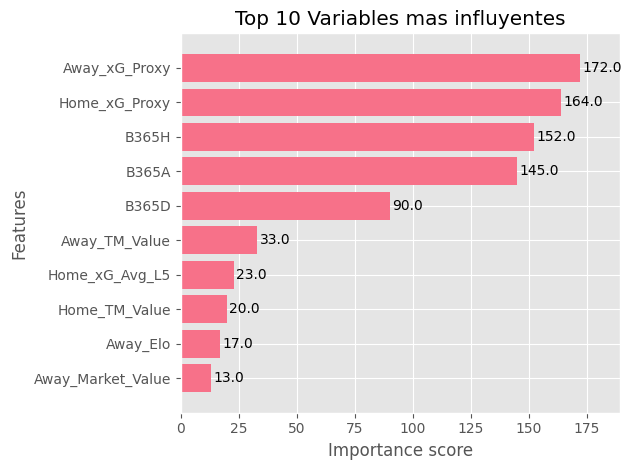

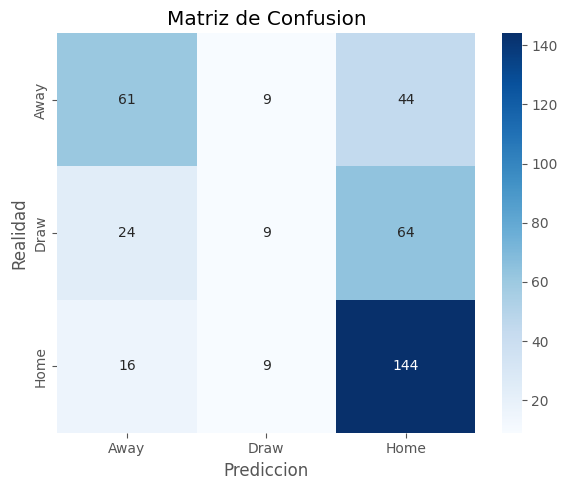

In [9]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, max_num_features=10, height=0.8, importance_type="weight")
plt.title("Top 10 Variables mas influyentes")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Away", "Draw", "Home"],
            yticklabels=["Away", "Draw", "Home"])
plt.xlabel("Prediccion")
plt.ylabel("Realidad")
plt.title("Matriz de Confusion")
plt.tight_layout()
plt.show()

## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.


WALK-FORWARD BACKTEST — 10 Temporadas de Test
Ventana de entrenamiento: 5 años
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

--- Fold 1: Train [2010, 2011, 2012, 2013, 2014] → Test 2015 (1900 train, 380 test) ---
    Log Loss: 0.9236 | Accuracy: 0.5763
    Apuestas con EV > 5%: 312

--- Fold 2: Train [2011, 2012, 2013, 2014, 2015] → Test 2016 (1900 train, 380 test) ---
    Log Loss: 0.9108 | Accuracy: 0.5921
    Apuestas con EV > 5%: 318

--- Fold 3: Train [2012, 2013, 2014, 2015, 2016] → Test 2017 (1900 train, 380 test) ---
    Log Loss: 0.9424 | Accuracy: 0.5605
    Apuestas con EV > 5%: 296

--- Fold 4: Train [2013, 2014, 2015, 2016, 2017] → Test 2018 (1900 train, 380 test) ---
    Log Loss: 0.9867 | Accuracy: 0.5289
    Apuestas con EV > 5%: 275

--- Fold 5: Train [2014, 2015, 2016, 2017, 2018] → Test 2019 (1900 train, 380 test) ---
    Log Loss: 0.9682 | Accuracy: 0.5395
    Apuestas con EV > 5%: 280

--- Fold 

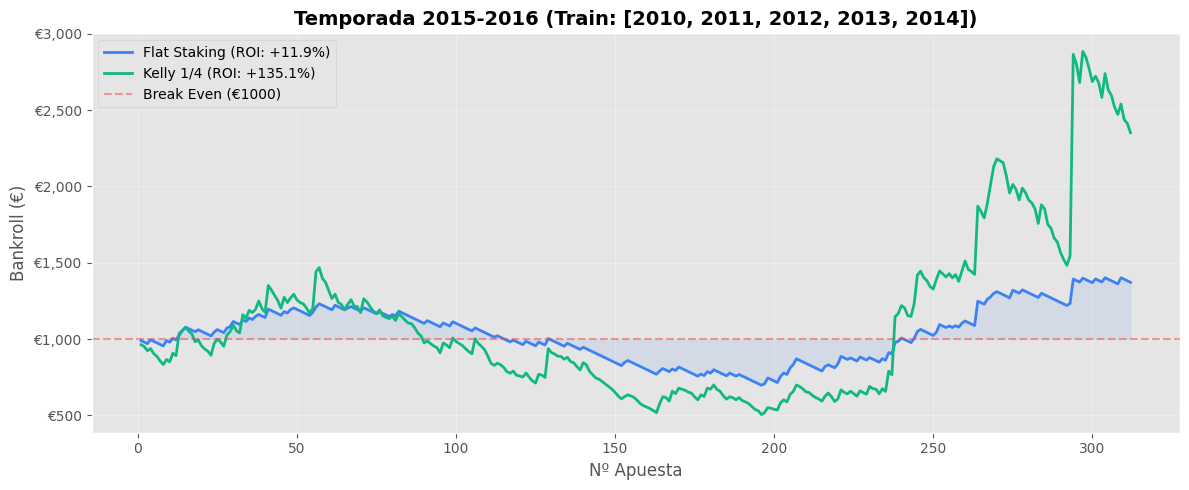


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2015-08-21 00:00:00,Malaga vs Sevilla FC,H,3.40,35.0%,€36.43,LOSS,€-36.43
2015-08-22 00:00:00,Ath Madrid vs UD Las Palmas,A,15.00,69.8%,€12.00,LOSS,€-12.00
2015-08-22 00:00:00,RCD Espanyol vs Getafe CF,A,4.33,39.1%,€27.95,LOSS,€-27.95
2015-08-22 00:00:00,Rayo Vallecano vs Valencia CF,D,3.50,6.1%,€5.59,WIN,€13.98
2015-08-22 00:00:00,La Coruna vs Real Sociedad,H,2.50,21.1%,€33.01,LOSS,€-33.01
2016-05-15 00:00:00,RCD Espanyol vs Eibar,A,3.70,20.1%,€46.91,LOSS,€-46.91
2016-05-15 00:00:00,Real Betis vs Getafe CF,H,5.00,11.0%,€16.94,WIN,€67.76
2016-05-15 00:00:00,Sporting Gijon vs Villarreal CF,A,7.50,103.8%,€101.34,LOSS,€-101.34
2016-05-15 00:00:00,Rayo Vallecano vs Levante UD,A,9.00,33.6%,€25.62,LOSS,€-25.62
2016-05-15 00:00:00,Malaga vs UD Las Palmas,A,4.50,35.4%,€60.97,LOSS,€-60.97



────────────────────────────────────────────────────────────
TEMPORADA 2016-2017
Entrenado con: [2011, 2012, 2013, 2014, 2015]
────────────────────────────────────────────────────────────
  Apuestas: 318  |  Aciertos: 73 (23.0%)
  ROI Flat: -0.51%  |  Bankroll: €984
  ROI Kelly: +19.89%  |  Bankroll: €1199

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   175    30   17.1%   -11.2%
     D    35    13   37.1%   +21.1%
     H   108    30   27.8%    +9.8%


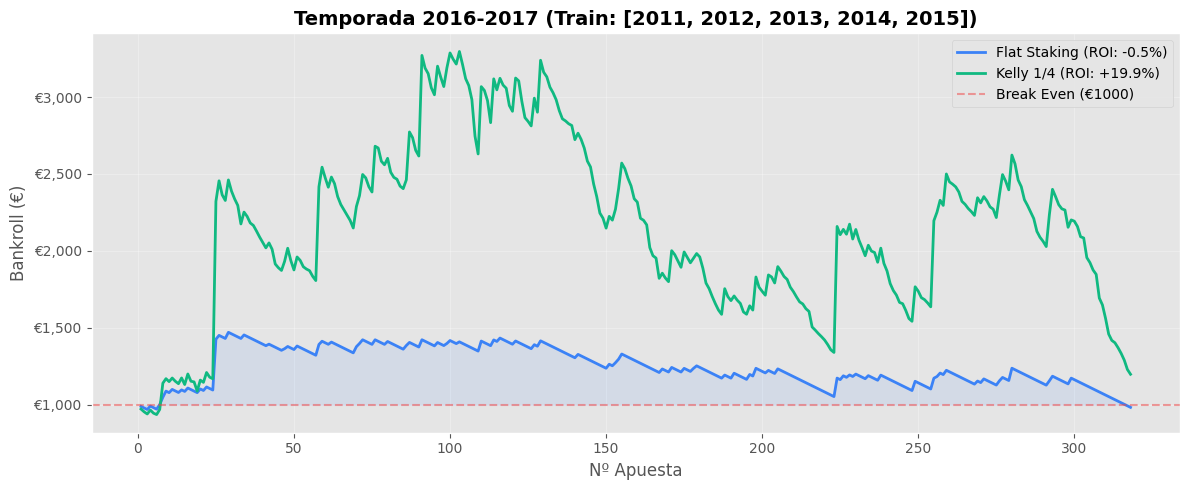


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2016-08-19 00:00:00,La Coruna vs Eibar,A,4.20,34.7%,€27.09,LOSS,€-27.09
2016-08-19 00:00:00,Malaga vs CA Osasuna,A,6.00,37.0%,€18.02,LOSS,€-18.02
2016-08-20 00:00:00,Sevilla FC vs RCD Espanyol,A,5.00,23.3%,€13.93,LOSS,€-13.93
2016-08-20 00:00:00,Granada CF vs Villarreal CF,D,3.20,10.7%,€11.49,WIN,€25.28
2016-08-20 00:00:00,FC Barcelona vs Real Betis,A,29.00,233.6%,€20.16,LOSS,€-20.16
2017-05-20 00:00:00,La Coruna vs UD Las Palmas,A,4.50,32.0%,€32.08,LOSS,€-32.08
2017-05-21 00:00:00,Valencia CF vs Villarreal CF,H,3.10,22.7%,€37.08,LOSS,€-37.08
2017-05-21 00:00:00,Celta Vigo vs Real Sociedad,H,4.75,49.5%,€44.00,LOSS,€-44.00
2017-05-21 00:00:00,Malaga vs Real Madrid,H,11.00,187.5%,€60.51,LOSS,€-60.51
2017-05-21 00:00:00,FC Barcelona vs Eibar,A,34.00,333.4%,€31.06,LOSS,€-31.06



────────────────────────────────────────────────────────────
TEMPORADA 2017-2018
Entrenado con: [2012, 2013, 2014, 2015, 2016]
────────────────────────────────────────────────────────────
  Apuestas: 296  |  Aciertos: 91 (30.7%)
  ROI Flat: +20.11%  |  Bankroll: €1595
  ROI Kelly: +552.92%  |  Bankroll: €6529

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   177    48   27.1%   +16.3%
     D    37    11   29.7%    +1.2%
     H    82    32   39.0%   +36.9%


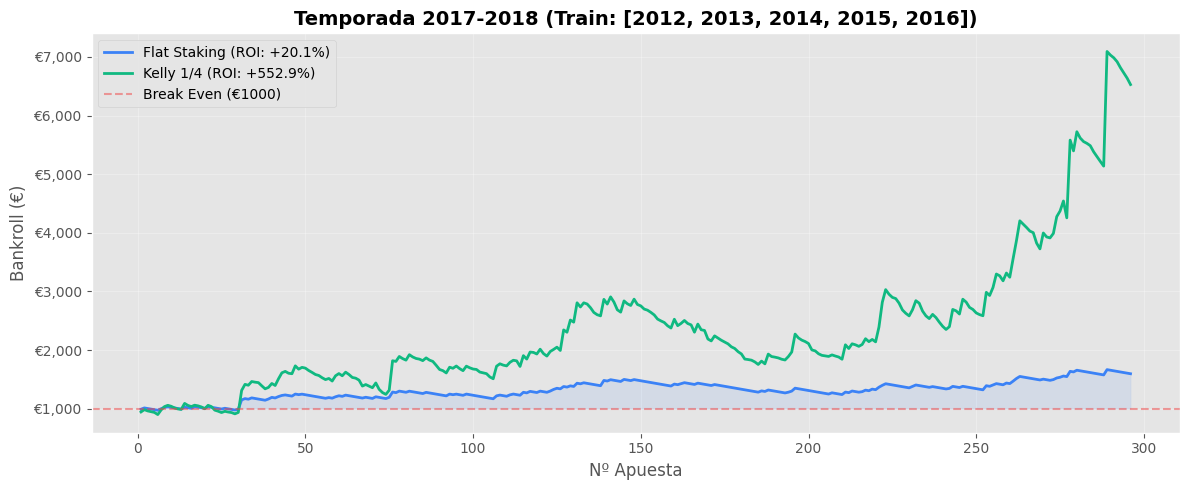


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2017-08-19 00:00:00,Girona FC vs Ath Madrid,H,8.00,158.9%,€56.74,LOSS,€-56.74
2017-08-19 00:00:00,Celta Vigo vs Real Sociedad,A,3.20,16.7%,€17.92,WIN,€39.42
2017-08-19 00:00:00,Sevilla FC vs RCD Espanyol,A,5.50,40.2%,€21.96,LOSS,€-21.96
2017-08-20 00:00:00,FC Barcelona vs Real Betis,A,15.00,70.9%,€12.16,LOSS,€-12.16
2017-08-20 00:00:00,Athletic Club vs Getafe CF,A,7.50,36.9%,€13.46,LOSS,€-13.46
2018-05-19 00:00:00,Malaga vs Getafe CF,D,3.30,8.8%,€67.05,LOSS,€-67.05
2018-05-19 00:00:00,Sevilla FC vs Alaves,A,8.00,41.5%,€102.56,LOSS,€-102.56
2018-05-20 00:00:00,Valencia CF vs La Coruna,A,8.00,37.3%,€90.79,LOSS,€-90.79
2018-05-20 00:00:00,FC Barcelona vs Real Sociedad,A,11.00,52.2%,€87.73,LOSS,€-87.73
2018-05-20 00:00:00,Ath Madrid vs Eibar,A,6.00,32.7%,€108.68,LOSS,€-108.68



────────────────────────────────────────────────────────────
TEMPORADA 2018-2019
Entrenado con: [2013, 2014, 2015, 2016, 2017]
────────────────────────────────────────────────────────────
  Apuestas: 275  |  Aciertos: 93 (33.8%)
  ROI Flat: +42.83%  |  Bankroll: €2178
  ROI Kelly: +1909.18%  |  Bankroll: €20092

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   154    45   29.2%   +44.2%
     D    36    16   44.4%   +50.8%
     H    85    32   37.6%   +37.0%


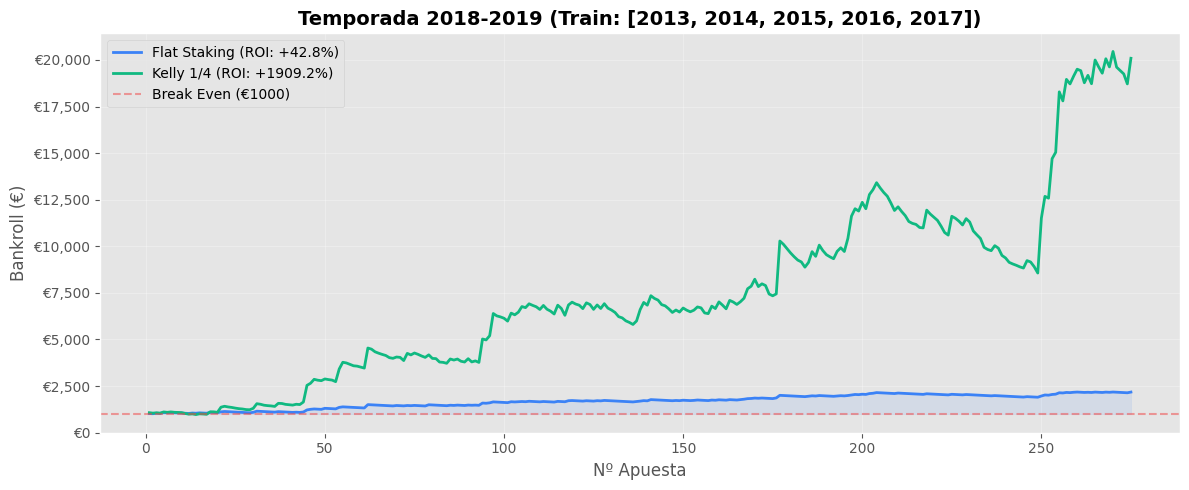


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2018-08-17 00:00:00,Girona FC vs Real Valladolid CF,D,3.60,28.5%,€27.39,WIN,€71.20
2018-08-18 00:00:00,Celta Vigo vs RCD Espanyol,A,4.50,29.5%,€22.56,LOSS,€-22.56
2018-08-18 00:00:00,Villarreal CF vs Real Sociedad,A,3.80,6.6%,€6.17,WIN,€17.29
2018-08-18 00:00:00,FC Barcelona vs Alaves,A,21.00,138.7%,€18.48,LOSS,€-18.48
2018-08-19 00:00:00,Eibar vs Huesca,A,5.50,24.6%,€14.32,WIN,€64.44
2019-05-18 00:00:00,Real Valladolid CF vs Valencia CF,H,8.00,115.0%,€840.46,LOSS,€-840.46
2019-05-18 00:00:00,Celta Vigo vs Rayo Vallecano,A,7.00,22.5%,€184.04,LOSS,€-184.04
2019-05-18 00:00:00,Sevilla FC vs Athletic Club,D,3.40,8.9%,€179.98,LOSS,€-179.98
2019-05-19 00:00:00,Eibar vs FC Barcelona,H,3.60,28.9%,€534.75,LOSS,€-534.75
2019-05-19 00:00:00,Real Madrid vs Real Betis,A,4.75,29.4%,€366.59,WIN,€1374.70



────────────────────────────────────────────────────────────
TEMPORADA 2019-2020
Entrenado con: [2014, 2015, 2016, 2017, 2018]
────────────────────────────────────────────────────────────
  Apuestas: 280  |  Aciertos: 87 (31.1%)
  ROI Flat: +20.16%  |  Bankroll: €1564
  ROI Kelly: +361.56%  |  Bankroll: €4616

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   141    26   18.4%   -17.2%
     D    60    29   48.3%   +63.6%
     H    79    32   40.5%   +53.7%


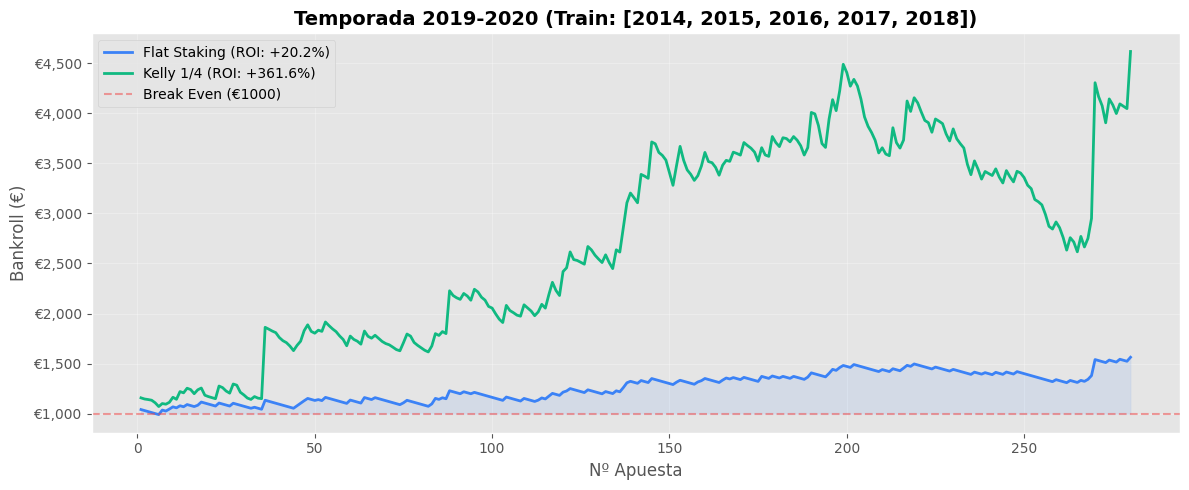


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2019-08-16 00:00:00,Athletic Club vs FC Barcelona,H,5.25,63.7%,€37.48,WIN,€159.30
2019-08-17 00:00:00,CD Leganes vs CA Osasuna,D,3.20,8.7%,€11.46,LOSS,€-11.46
2019-08-17 00:00:00,Celta Vigo vs Real Madrid,H,4.75,7.0%,€5.34,LOSS,€-5.34
2019-08-17 00:00:00,Valencia CF vs Real Sociedad,A,5.50,10.8%,€6.85,LOSS,€-6.85
2019-08-17 00:00:00,Villarreal CF vs Granada CF,A,6.50,49.7%,€25.65,LOSS,€-25.65
2020-07-19 00:00:00,RCD Espanyol vs Celta Vigo,H,5.00,33.8%,€86.34,LOSS,€-86.34
2020-07-19 00:00:00,CD Leganes vs Real Madrid,D,3.80,9.6%,€34.41,WIN,€96.34
2020-07-19 00:00:00,Alaves vs FC Barcelona,D,4.33,7.6%,€23.47,LOSS,€-23.47
2020-07-19 00:00:00,Villarreal CF vs Eibar,A,6.00,11.5%,€23.40,LOSS,€-23.40
2020-07-19 00:00:00,Levante UD vs Getafe CF,H,5.00,56.3%,€142.48,WIN,€569.93



────────────────────────────────────────────────────────────
TEMPORADA 2020-2021
Entrenado con: [2015, 2016, 2017, 2018, 2019]
────────────────────────────────────────────────────────────
  Apuestas: 290  |  Aciertos: 90 (31.0%)
  ROI Flat: +22.94%  |  Bankroll: €1665
  ROI Kelly: +402.49%  |  Bankroll: €5025

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   117    32   27.4%   +31.0%
     D    92    36   39.1%   +34.8%
     H    81    22   27.2%    -2.1%


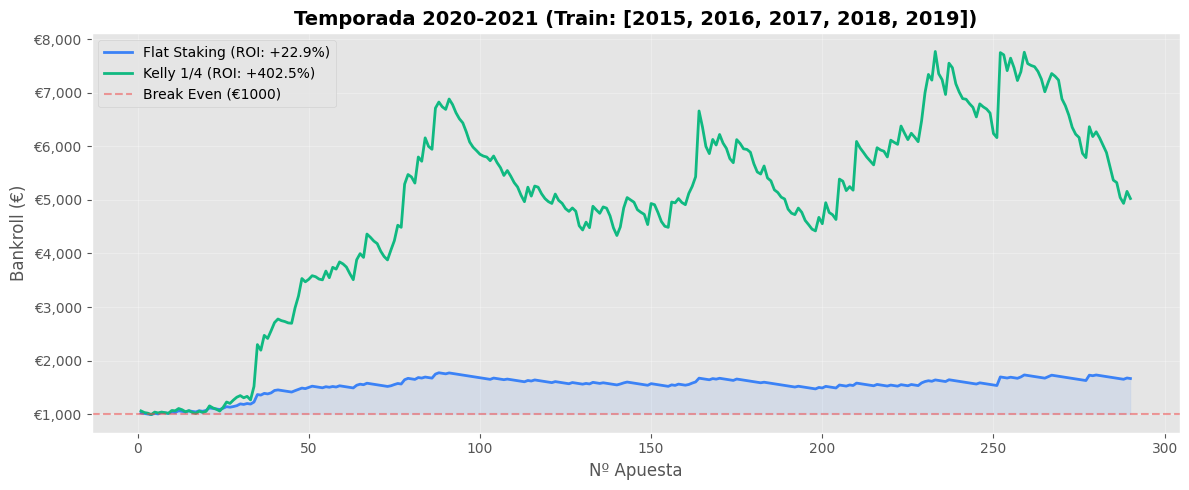


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2020-09-12 00:00:00,Eibar vs Celta Vigo,D,3.25,24.1%,€26.77,WIN,€60.24
2020-09-12 00:00:00,Granada CF vs Athletic Club,D,3.10,23.9%,€30.21,LOSS,€-30.21
2020-09-12 00:00:00,Cadiz CF vs CA Osasuna,D,3.00,9.0%,€11.61,LOSS,€-11.61
2020-09-13 00:00:00,Alaves vs Real Betis,D,3.20,22.4%,€25.89,LOSS,€-25.89
2020-09-13 00:00:00,Real Valladolid CF vs Real Sociedad,D,3.20,18.5%,€20.87,WIN,€45.90
2021-05-22 00:00:00,Huesca vs Valencia CF,A,5.00,13.6%,€45.70,LOSS,€-45.70
2021-05-22 00:00:00,CA Osasuna vs Real Sociedad,D,4.33,69.6%,€278.00,LOSS,€-278.00
2021-05-22 00:00:00,Elche CF vs Athletic Club,D,3.60,22.8%,€110.57,LOSS,€-110.57
2021-05-23 00:00:00,Granada CF vs Getafe CF,D,3.40,18.2%,€93.48,WIN,€224.36
2021-05-23 00:00:00,Sevilla FC vs Alaves,D,4.33,34.6%,€133.95,LOSS,€-133.95



────────────────────────────────────────────────────────────
TEMPORADA 2021-2022
Entrenado con: [2016, 2017, 2018, 2019, 2020]
────────────────────────────────────────────────────────────
  Apuestas: 287  |  Aciertos: 83 (28.9%)
  ROI Flat: +8.00%  |  Bankroll: €1230
  ROI Kelly: +87.09%  |  Bankroll: €1871

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   133    31   23.3%    -0.1%
     D    75    24   32.0%   +10.7%
     H    79    28   35.4%   +19.0%


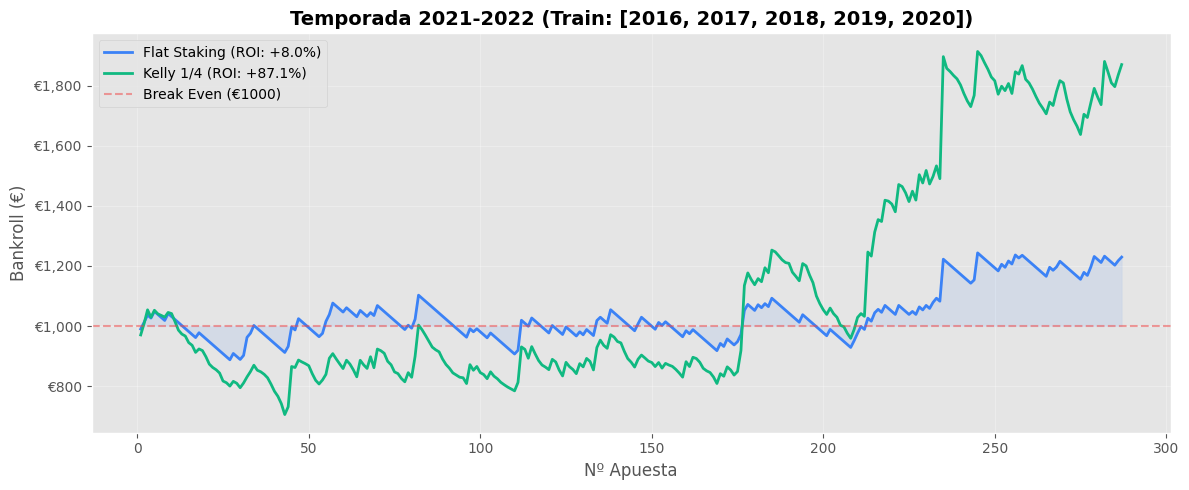


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2021-08-13 00:00:00,Valencia CF vs Getafe CF,A,3.10,24.9%,€29.70,LOSS,€-29.70
2021-08-14 00:00:00,Cadiz CF vs Levante UD,D,3.25,15.8%,€17.04,WIN,€38.34
2021-08-14 00:00:00,RCD Mallorca vs Real Betis,D,3.40,17.9%,€18.83,WIN,€45.18
2021-08-14 00:00:00,Alaves vs Real Madrid,H,7.00,56.8%,€24.92,LOSS,€-24.92
2021-08-14 00:00:00,CA Osasuna vs RCD Espanyol,D,3.20,9.1%,€10.69,WIN,€23.53
2022-05-22 00:00:00,FC Barcelona vs Villarreal CF,D,4.00,22.1%,€34.65,LOSS,€-34.65
2022-05-22 00:00:00,Granada CF vs RCD Espanyol,A,7.50,51.7%,€36.72,LOSS,€-36.72
2022-05-22 00:00:00,Alaves vs Cadiz CF,D,3.70,7.5%,€12.61,LOSS,€-12.61
2022-05-22 00:00:00,Sevilla FC vs Athletic Club,H,2.50,8.6%,€25.89,WIN,€38.83
2022-05-22 00:00:00,CA Osasuna vs RCD Mallorca,A,2.20,7.6%,€28.89,WIN,€34.66



────────────────────────────────────────────────────────────
TEMPORADA 2022-2023
Entrenado con: [2017, 2018, 2019, 2020, 2021]
────────────────────────────────────────────────────────────
  Apuestas: 264  |  Aciertos: 86 (32.6%)
  ROI Flat: +19.33%  |  Bankroll: €1510
  ROI Kelly: +353.23%  |  Bankroll: €4532

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   118    30   25.4%    +9.7%
     D    60    18   30.0%    +1.5%
     H    86    38   44.2%   +45.0%


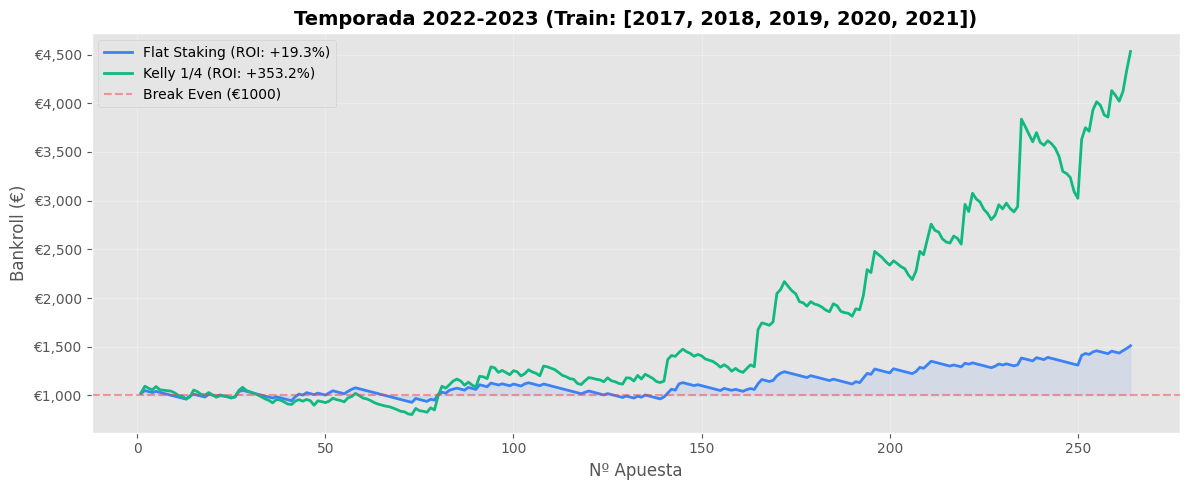


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2022-08-12 00:00:00,CA Osasuna vs Sevilla FC,H,3.20,9.7%,€10.99,WIN,€24.17
2022-08-13 00:00:00,Celta Vigo vs RCD Espanyol,D,3.75,27.4%,€25.49,WIN,€70.11
2022-08-13 00:00:00,Real Valladolid CF vs Villarreal CF,H,3.90,22.0%,€20.71,LOSS,€-20.71
2022-08-13 00:00:00,FC Barcelona vs Rayo Vallecano,A,12.00,68.6%,€16.74,LOSS,€-16.74
2022-08-14 00:00:00,Cadiz CF vs Real Sociedad,A,2.20,13.1%,€28.85,WIN,€34.62
2023-06-04 00:00:00,RCD Mallorca vs Rayo Vallecano,A,2.38,6.6%,€49.12,LOSS,€-49.12
2023-06-04 00:00:00,RCD Espanyol vs UD Almeria,H,2.75,10.2%,€59.55,LOSS,€-59.55
2023-06-04 00:00:00,Villarreal CF vs Ath Madrid,D,3.50,10.0%,€40.26,WIN,€100.65
2023-06-04 00:00:00,Real Valladolid CF vs Getafe CF,D,3.30,21.3%,€95.45,WIN,€219.54
2023-06-04 00:00:00,Real Madrid vs Athletic Club,D,3.75,17.5%,€69.11,WIN,€190.04



────────────────────────────────────────────────────────────
TEMPORADA 2023-2024
Entrenado con: [2018, 2019, 2020, 2021, 2022]
────────────────────────────────────────────────────────────
  Apuestas: 295  |  Aciertos: 70 (23.7%)
  ROI Flat: -20.05%  |  Bankroll: €408
  ROI Kelly: -73.02%  |  Bankroll: €270

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   122    24   19.7%   -28.4%
     D    78    26   33.3%   +15.9%
     H    95    20   21.1%   -38.8%


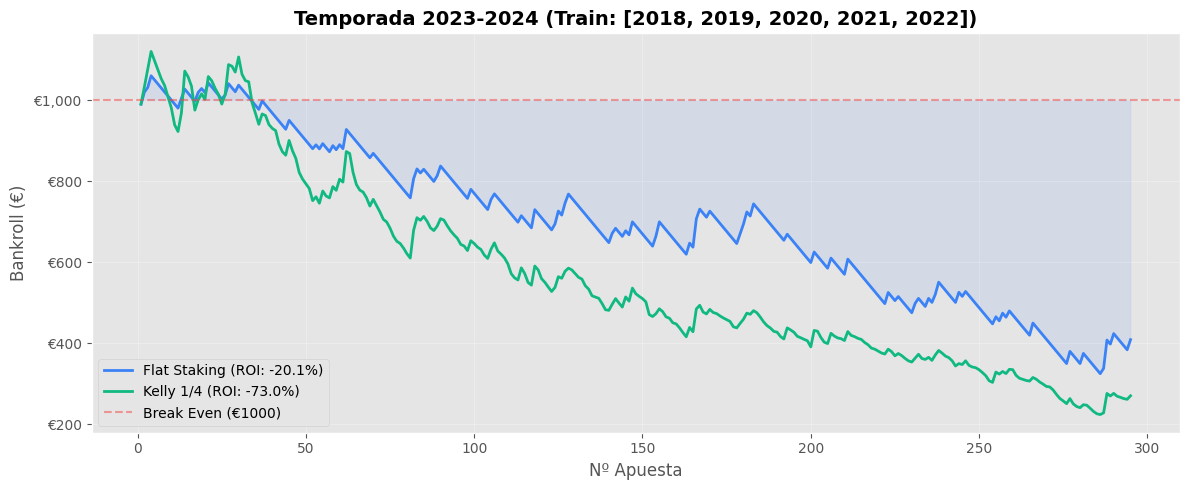


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2023-08-11 00:00:00,Sevilla FC vs Valencia CF,D,3.50,9.1%,€9.13,LOSS,€-9.13
2023-08-12 00:00:00,Real Sociedad vs Girona FC,D,4.00,16.9%,€13.96,WIN,€41.87
2023-08-12 00:00:00,Athletic Club vs Real Madrid,A,2.15,16.9%,€37.84,WIN,€43.51
2023-08-13 00:00:00,Celta Vigo vs CA Osasuna,A,3.90,16.4%,€15.24,WIN,€44.18
2023-08-13 00:00:00,Getafe CF vs FC Barcelona,H,6.50,44.1%,€22.49,LOSS,€-22.49
2024-05-25 00:00:00,Rayo Vallecano vs Athletic Club,H,2.88,19.2%,€7.03,LOSS,€-7.03
2024-05-25 00:00:00,Real Sociedad vs Ath Madrid,D,3.30,9.3%,€2.73,LOSS,€-2.73
2024-05-25 00:00:00,Real Madrid vs Real Betis,A,7.50,31.0%,€3.17,LOSS,€-3.17
2024-05-26 00:00:00,Sevilla FC vs FC Barcelona,H,4.00,8.1%,€1.76,LOSS,€-1.76
2024-05-26 00:00:00,Celta Vigo vs Valencia CF,D,3.50,13.3%,€3.49,WIN,€8.71



────────────────────────────────────────────────────────────
TEMPORADA 2024-2025
Entrenado con: [2019, 2020, 2021, 2022, 2023]
────────────────────────────────────────────────────────────
  Apuestas: 260  |  Aciertos: 68 (26.2%)
  ROI Flat: +8.80%  |  Bankroll: €1229
  ROI Kelly: +108.86%  |  Bankroll: €2089

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   122    31   25.4%   +20.6%
     D    66    17   25.8%    -9.6%
     H    72    20   27.8%    +5.7%


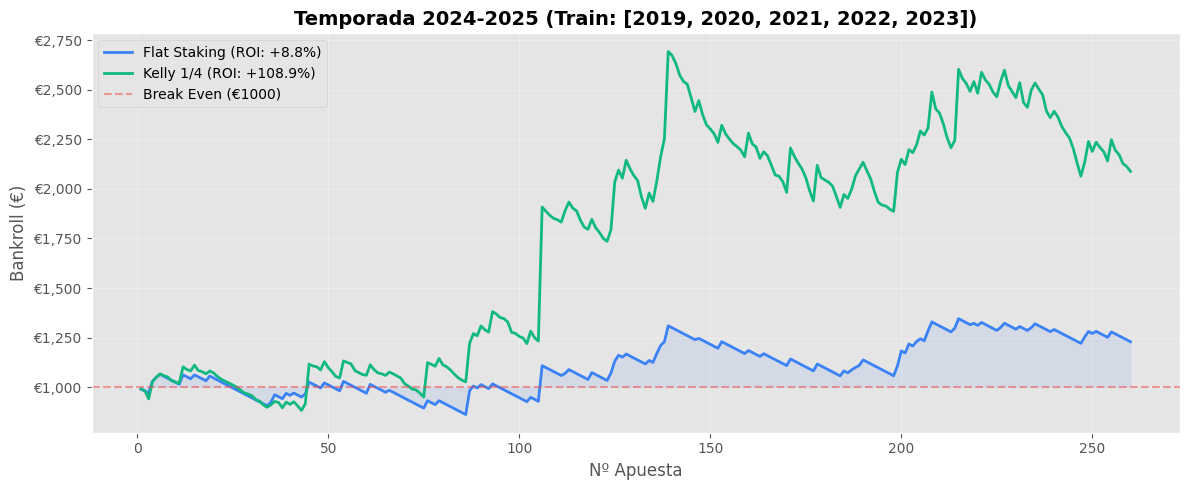


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2024-08-15 00:00:00,Athletic Club vs Getafe CF,A,8.00,28.7%,€10.24,LOSS,€-10.24
2024-08-16 00:00:00,Celta Vigo vs Alaves,D,3.20,6.1%,€6.89,LOSS,€-6.89
2024-08-18 00:00:00,RCD Mallorca vs Real Madrid,H,8.00,120.4%,€42.28,LOSS,€-42.28
2024-08-18 00:00:00,Real Sociedad vs Rayo Vallecano,A,7.00,36.7%,€14.40,WIN,€86.38
2024-08-24 00:00:00,Getafe CF vs Rayo Vallecano,D,3.00,8.8%,€11.28,WIN,€22.56
2025-05-24 00:00:00,RCD Espanyol vs UD Las Palmas,A,8.00,66.0%,€53.01,LOSS,€-53.01
2025-05-24 00:00:00,Alaves vs CA Osasuna,A,2.35,5.6%,€22.60,LOSS,€-22.60
2025-05-24 00:00:00,CD Leganes vs Real Valladolid CF,A,9.50,69.8%,€44.63,LOSS,€-44.63
2025-05-24 00:00:00,Getafe CF vs Celta Vigo,D,3.75,7.9%,€15.32,LOSS,€-15.32
2025-05-25 00:00:00,Villarreal CF vs Sevilla FC,A,6.00,23.3%,€24.58,LOSS,€-24.58



RESUMEN GLOBAL — TODAS LAS TEMPORADAS


,bets,wins,hit_rate,flat_roi,flat_final,kelly_roi,kelly_final
season,,,,,,,
2015,312,94,30.1,11.91,1372.0,135.11,2351.0
2016,318,73,23.0,-0.51,984.0,19.89,1199.0
2017,296,91,30.7,20.11,1595.0,552.92,6529.0
2018,275,93,33.8,42.83,2178.0,1909.18,20092.0
2019,280,87,31.1,20.16,1564.0,361.56,4616.0
2020,290,90,31.0,22.94,1665.0,402.49,5025.0
2021,287,83,28.9,8.00,1230.0,87.09,1871.0
2022,264,86,32.6,19.33,1510.0,353.23,4532.0
2023,295,70,23.7,-20.05,408.0,-73.02,270.0



Media ROI Flat: +13.35%
Total apuestas: 2877
Total aciertos: 835 (29.0%)


In [ ]:
# ============================================================
# BACKTEST: Walk-Forward por Temporadas con Apuestas Combinadas
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import log_loss, accuracy_score

# --- Configuración ---
INITIAL_BANKROLL = 1000
FLAT_STAKE = 10
MIN_EV = 0.05        # Solo apostar si EV > 5%
KELLY_FRACTION = 0.25 # Cuarto Kelly (más conservador)
WINDOW_SIZE = 5       # Años de entrenamiento

# --- Preparar datos ---
df_bt = df.copy()

# DEDUPLICAR: Season 2024 contiene filas duplicadas (3040 vs 380 esperadas)
# Identificamos duplicados por Date + HomeTeam + AwayTeam y nos quedamos con el primero
before = len(df_bt)
df_bt = df_bt.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first')
after = len(df_bt)
if before != after:
    print(f"⚠️ Se eliminaron {before - after} filas duplicadas ({before} → {after})")

odds_cols = ['B365H', 'B365D', 'B365A']

# Verificar que las cuotas existen
has_odds = all(c in df_bt.columns for c in odds_cols)
if not has_odds:
    print('⚠️ Columnas de cuotas B365 no encontradas. Backtest no disponible.')
else:
    # Eliminar filas sin cuotas
    df_bt = df_bt.dropna(subset=odds_cols + features + ['Target'])
    df_bt = df_bt.sort_values('Date').reset_index(drop=True)
    
    # --- Walk-Forward por Temporadas ---
    seasons_bt = sorted(df_bt['Season'].unique())
    n_folds = len(seasons_bt) - WINDOW_SIZE
    
    print(f"\n{'='*60}")
    print(f"WALK-FORWARD BACKTEST — {n_folds} Temporadas de Test")
    print(f"Ventana de entrenamiento: {WINDOW_SIZE} años")
    print(f"Temporadas disponibles: {seasons_bt}")
    print(f"{'='*60}")
    
    all_season_results = {}  # dict: season -> list of bet results
    
    for fold_i in range(n_folds):
        fold = fold_i + 1
        train_seasons = seasons_bt[fold_i : fold_i + WINDOW_SIZE]
        test_season   = seasons_bt[fold_i + WINDOW_SIZE]
        
        train_mask = df_bt['Season'].isin(train_seasons)
        test_mask  = df_bt['Season'] == test_season
        
        X_train_f = df_bt.loc[train_mask, features].astype(float)
        y_train_f = df_bt.loc[train_mask, 'Target'].astype(int)
        X_test_f  = df_bt.loc[test_mask,  features].astype(float)
        y_test_f  = df_bt.loc[test_mask,  'Target'].astype(int)
        
        n_train = len(X_train_f)
        n_test  = len(X_test_f)
        
        # --- Entrenar modelo ---
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        bt_model = xgb.XGBClassifier(**_params)
        bt_model.fit(X_train_f, y_train_f)
        
        # --- Predecir ---
        proba = bt_model.predict_proba(X_test_f)
        preds = bt_model.predict(X_test_f)
        ll = log_loss(y_test_f, proba)
        acc = accuracy_score(y_test_f, preds)
        
        print(f"\n--- Fold {fold}: Train {train_seasons} → Test {int(test_season)} "
              f"({n_train} train, {n_test} test) ---")
        print(f"    Log Loss: {ll:.4f} | Accuracy: {acc:.4f}")
        
        # --- Evaluar apuestas ---
        test_indices = df_bt.index[test_mask].tolist()
        season_results = []
        
        for j, idx in enumerate(test_indices):
            row = df_bt.iloc[idx]
            p_A, p_D, p_H = proba[j]  # Mapping: A=0, D=1, H=2
            
            odds_H = row['B365H']
            odds_D = row['B365D']
            odds_A = row['B365A']
            actual = int(row['Target'])  # 0=A, 1=D, 2=H
            
            # === APUESTAS SIMPLES ===
            bets = []
            # Home win
            bets.append(('H', p_H, odds_H, actual == 2))
            # Draw
            bets.append(('D', p_D, odds_D, actual == 1))
            # Away win
            bets.append(('A', p_A, odds_A, actual == 0))
            
            # === APUESTAS COMBINADAS (Doble Oportunidad) ===
            # 1X = Home o Draw
            p_1X = p_H + p_D
            odds_1X = 1.0 / (1.0/odds_H + 1.0/odds_D)
            bets.append(('1X', p_1X, odds_1X, actual in (1, 2)))
            
            # X2 = Draw o Away
            p_X2 = p_D + p_A
            odds_X2 = 1.0 / (1.0/odds_D + 1.0/odds_A)
            bets.append(('X2', p_X2, odds_X2, actual in (0, 1)))
            
            # 12 = Home o Away
            p_12 = p_H + p_A
            odds_12 = 1.0 / (1.0/odds_H + 1.0/odds_A)
            bets.append(('12', p_12, odds_12, actual in (0, 2)))
            
            # --- Calcular EV y elegir la mejor ---
            best_bet = None
            best_ev_val = -999
            for (bet_name, prob, odds_val, won) in bets:
                ev = (prob * odds_val) - 1
                if ev > best_ev_val:
                    best_ev_val = ev
                    best_bet = (bet_name, prob, odds_val, won, ev)
            
            if best_bet is not None and best_ev_val > MIN_EV:
                bet_name, prob, odds_val, won, ev = best_bet
                kelly = max(0, (prob * odds_val - 1) / (odds_val - 1)) * KELLY_FRACTION
                
                season_results.append({
                    'date': row['Date'],
                    'home': row.get('HomeTeam', ''),
                    'away': row.get('AwayTeam', ''),
                    'bet': bet_name,
                    'odds': odds_val,
                    'prob': prob,
                    'ev': ev,
                    'won': won,
                    'kelly_pct': kelly,
                    'fold': fold
                })
        
        all_season_results[int(test_season)] = season_results
        print(f"    Apuestas con EV > {MIN_EV*100:.0f}%: {len(season_results)}")

    # ================================================================
    # GRÁFICAS POR TEMPORADA
    # ================================================================
    print(f"\n{'='*60}")
    print("RESULTADOS POR TEMPORADA")
    print(f"{'='*60}")
    
    global_summary = []
    
    for season_year in sorted(all_season_results.keys()):
        results = all_season_results[season_year]
        if not results:
            print(f"\nTemporada {season_year}: Sin apuestas con EV > {MIN_EV*100:.0f}%")
            continue
        
        df_res = pd.DataFrame(results)
        df_res['date'] = pd.to_datetime(df_res['date'])
        df_res = df_res.sort_values('date').reset_index(drop=True)
        
        # Flat staking P&L
        df_res['flat_pnl'] = df_res.apply(
            lambda r: FLAT_STAKE * (r['odds'] - 1) if r['won'] else -FLAT_STAKE, axis=1
        )
        df_res['flat_cumsum'] = INITIAL_BANKROLL + df_res['flat_pnl'].cumsum()
        
        # Kelly P&L
        kelly_bank = INITIAL_BANKROLL
        kelly_curve = []
        kelly_stakes = []
        
        for _, r in df_res.iterrows():
            stake = kelly_bank * r['kelly_pct']
            kelly_stakes.append(stake)
            if r['won']:
                kelly_bank += stake * (r['odds'] - 1)
            else:
                kelly_bank -= stake
            kelly_curve.append(kelly_bank)
        
        df_res['kelly_cumsum'] = kelly_curve
        df_res['kelly_stake'] = kelly_stakes
        
        # --- Métricas ---
        total_bets = len(df_res)
        wins = int(df_res['won'].sum())
        hit_rate = wins / total_bets * 100
        flat_roi = df_res['flat_pnl'].sum() / (total_bets * FLAT_STAKE) * 100
        kelly_roi = (kelly_bank - INITIAL_BANKROLL) / INITIAL_BANKROLL * 100
        flat_final = df_res['flat_cumsum'].iloc[-1]
        
        # Desglose por tipo de apuesta
        bet_breakdown = df_res.groupby('bet').agg(
            n=('won', 'count'),
            wins=('won', 'sum'),
            pnl=('flat_pnl', 'sum')
        )
        bet_breakdown['hit'] = (bet_breakdown['wins'] / bet_breakdown['n'] * 100).round(1)
        bet_breakdown['roi'] = (bet_breakdown['pnl'] / (bet_breakdown['n'] * FLAT_STAKE) * 100).round(1)
        
        # Temporadas de entrenamiento usadas
        fold_idx = season_year - seasons_bt[WINDOW_SIZE]
        train_used = seasons_bt[fold_idx : fold_idx + WINDOW_SIZE]
        
        print(f"\n{'─'*60}")
        print(f"TEMPORADA {season_year}-{season_year+1}")
        print(f"Entrenado con: {list(map(int, train_used))}")
        print(f"{'─'*60}")
        print(f"  Apuestas: {total_bets}  |  Aciertos: {wins} ({hit_rate:.1f}%)")
        print(f"  ROI Flat: {flat_roi:+.2f}%  |  Bankroll: €{flat_final:.0f}")
        print(f"  ROI Kelly: {kelly_roi:+.2f}%  |  Bankroll: €{kelly_bank:.0f}")
        print(f"\n  Desglose por tipo de apuesta:")
        print(f"  {'Tipo':>4s}  {'N':>4s}  {'Wins':>4s}  {'Hit%':>6s}  {'ROI%':>7s}")
        for bt_name, bt_row in bet_breakdown.iterrows():
            print(f"  {bt_name:>4s}  {int(bt_row['n']):>4d}  {int(bt_row['wins']):>4d}  "
                  f"{bt_row['hit']:>5.1f}%  {bt_row['roi']:>+6.1f}%")
        
        global_summary.append({
            'season': f"{season_year}",
            'bets': total_bets,
            'wins': wins,
            'hit_rate': round(hit_rate, 1),
            'flat_roi': round(flat_roi, 2),
            'flat_final': round(flat_final, 0),
            'kelly_roi': round(kelly_roi, 2),
            'kelly_final': round(kelly_bank, 0)
        })
        
        # === GRÁFICA POR TEMPORADA ===
        fig, ax = plt.subplots(figsize=(12, 5))
        
        bet_numbers = range(1, total_bets + 1)
        
        ax.plot(bet_numbers, df_res['flat_cumsum'], 
                label=f'Flat Staking (ROI: {flat_roi:+.1f}%)', 
                color='#3b82f6', linewidth=2)
        ax.plot(bet_numbers, df_res['kelly_cumsum'], 
                label=f'Kelly 1/4 (ROI: {kelly_roi:+.1f}%)', 
                color='#10b981', linewidth=2)
        ax.axhline(y=INITIAL_BANKROLL, color='#ef4444', linestyle='--', 
                   alpha=0.5, label='Break Even (€1000)')
        ax.fill_between(bet_numbers, INITIAL_BANKROLL, df_res['flat_cumsum'], 
                        alpha=0.1, color='#3b82f6')
        
        ax.set_title(f'Temporada {season_year}-{season_year+1} '
                     f'(Train: {list(map(int, train_used))})', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Nº Apuesta')
        ax.set_ylabel('Bankroll (€)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
        plt.tight_layout()
        plt.show()

        # === TABLA DETALLE DE APUESTAS ===
        print(f"\n  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<")
        df_disp = df_res.copy()
        df_disp['Match'] = df_disp['home'] + ' vs ' + df_disp['away']
        df_disp['Result'] = df_disp['won'].map({True: 'WIN', False: 'LOSS'})
        df_disp['Profit'] = df_disp.apply(lambda r: r['kelly_stake'] * (r['odds'] - 1) if r['won'] else -r['kelly_stake'], axis=1)
        
        cols_show = ['date', 'Match', 'bet', 'odds', 'ev', 'kelly_stake', 'Result', 'Profit']
        
        # Formato para mostrar
        format_dict = {'ev': '{:.1%}', 'kelly_stake': '€{:.2f}', 'Profit': '€{:.2f}', 'odds': '{:.2f}'}
        
        if len(df_disp) > 10:
            df_show = pd.concat([df_disp[cols_show].head(5), df_disp[cols_show].tail(5)])
        else:
            df_show = df_disp[cols_show]
            
        # Check if we are in an IPython environment for display(), else print
        try:
             # Just simple styling if display is available (it is in Jupyter)
             display(df_show.style.format(format_dict).hide(axis='index'))
        except:
             print(df_show.to_string())

    # === TABLA RESUMEN GLOBAL ===
    if global_summary:
        print(f"\n{'='*60}")
        print("RESUMEN GLOBAL — TODAS LAS TEMPORADAS")
        print(f"{'='*60}")
        df_summary = pd.DataFrame(global_summary)
        display(df_summary.set_index('season'))
        
        avg_roi = df_summary['flat_roi'].mean()
        total_bets_all = df_summary['bets'].sum()
        total_wins_all = df_summary['wins'].sum()
        print(f"\nMedia ROI Flat: {avg_roi:+.2f}%")
        print(f"Total apuestas: {total_bets_all}")
        print(f"Total aciertos: {total_wins_all} ({total_wins_all/total_bets_all*100:.1f}%)")


## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.

In [11]:
# [CELDA ELIMINADA — Backtest consolidado en celda anterior]
